In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#sns.set_style("whitegrid")
#sns.set_context("talk")
plt.rcParams['axes.facecolor'] = "#f5f5dc"

In [86]:
dff = pd.read_csv('train.csv')
dff.set_index('id', inplace = True)
dff

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19


In [87]:
dff.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


In [88]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


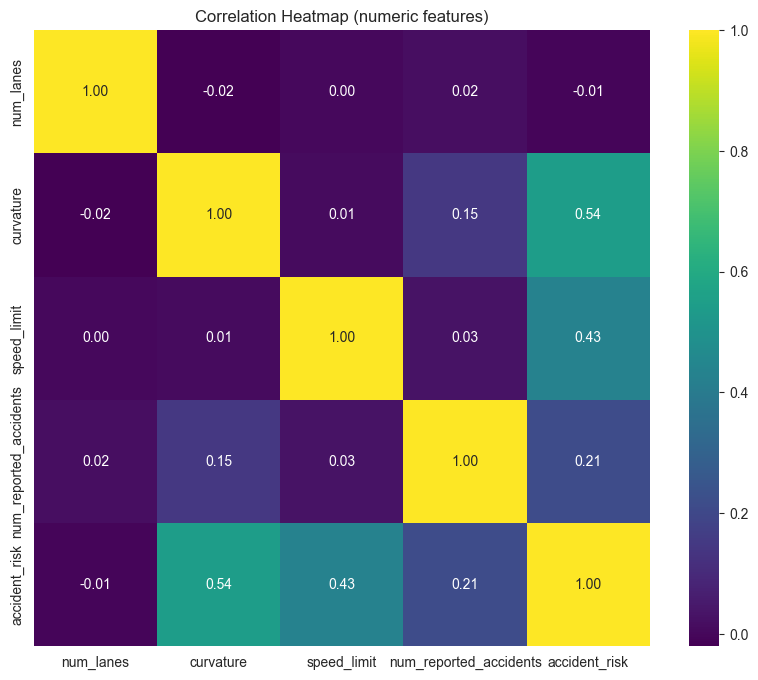

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = dff.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f", square=True)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

In [90]:
sns.set_style("whitegrid")
plt.rcParams['axes.facecolor'] = "#f5f5dc"

In [91]:
# Załóżmy, że df jest bardzo duży, np. milion wierszy
df = dff.sample(n=1000, random_state=42)  # losowa próbka 1000 wierszy

C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2583224310.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='accident_risk', data=mean_risk, ax=axes[i], palette='viridis')
C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2583224310.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='accident_risk', data=mean_risk, ax=axes[i], palette='viridis')
C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2583224310.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='accident_risk', data=mean_risk, ax=axes[

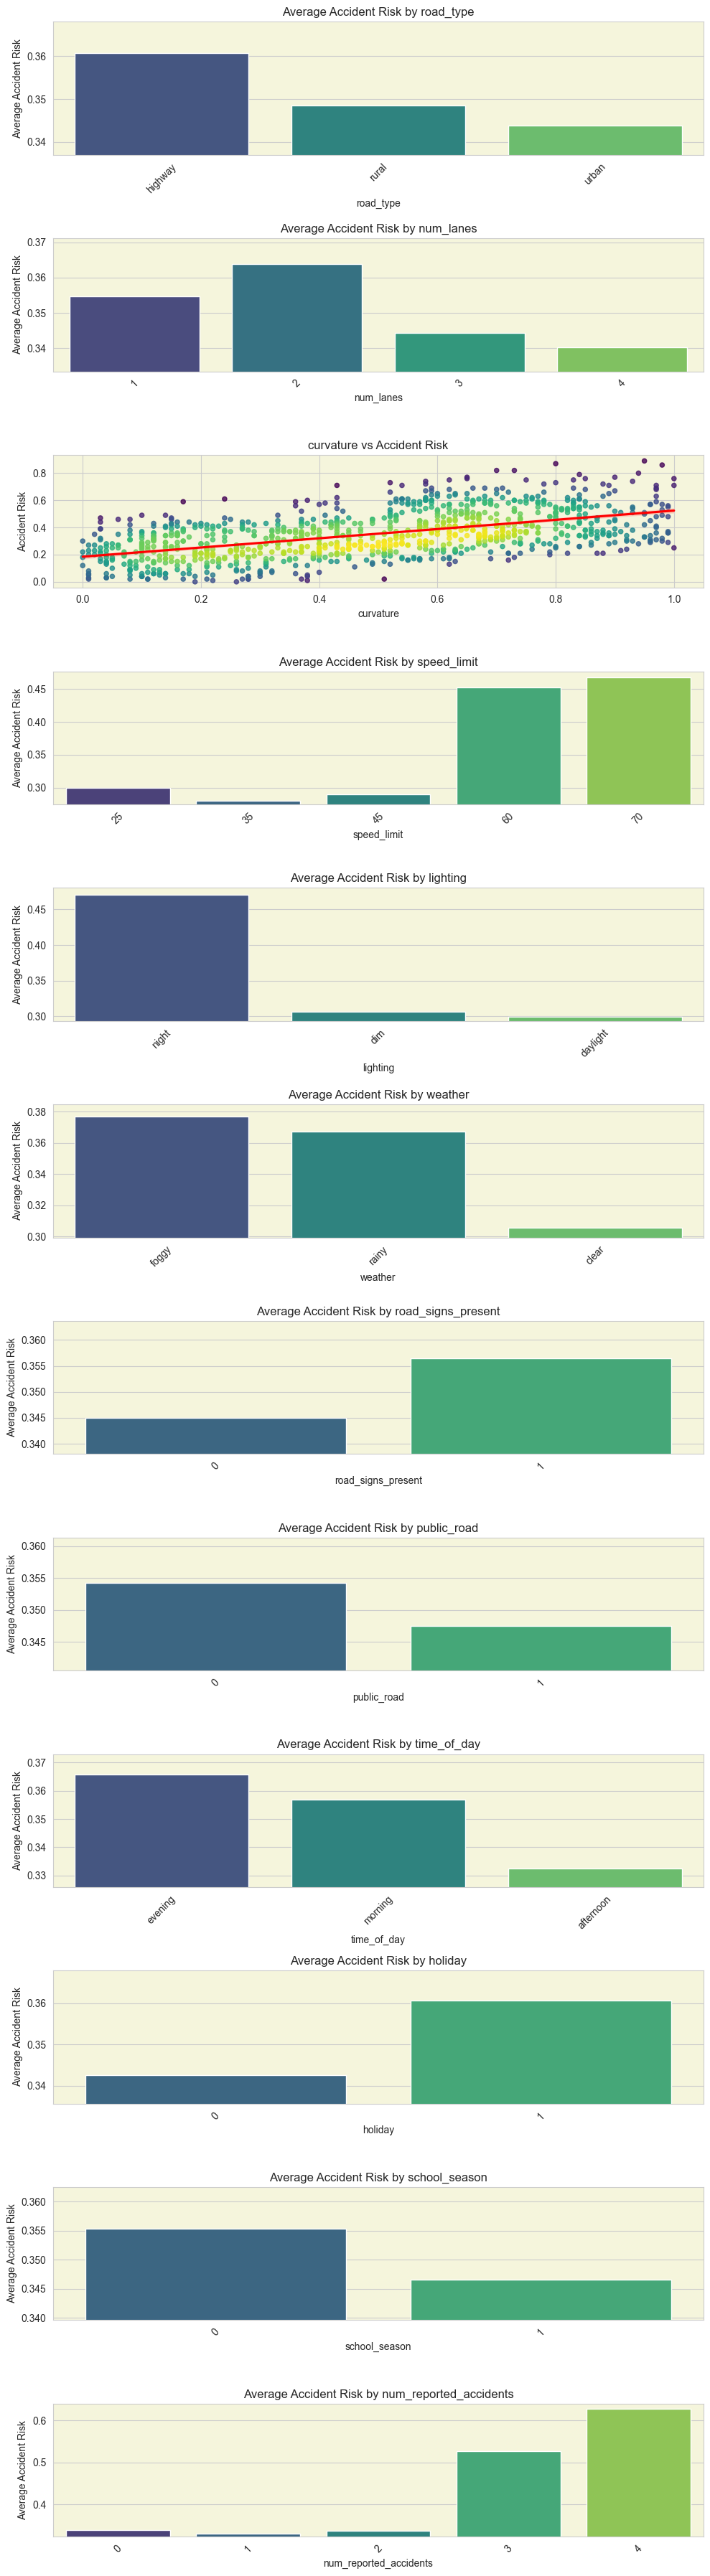

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# --- Convert boolean columns to int ---
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# --- Identify all features except target ---
all_features = df.columns.drop('accident_risk')

# --- Create subplots dynamically ---
fig, axes = plt.subplots(len(all_features), 1, figsize=(10, 3 * len(all_features)))
if len(all_features) == 1:
    axes = [axes]

for i, feature in enumerate(all_features):

    # --- Categorical / bool / low-cardinality features ---
    if df[feature].dtype == 'object' or df[feature].nunique() <= 6:
        mean_risk = df.groupby(feature)['accident_risk'].mean().reset_index()
        mean_risk = mean_risk.sort_values('accident_risk', ascending=False)

        sns.barplot(x=feature, y='accident_risk', data=mean_risk, ax=axes[i], palette='viridis')
        axes[i].set_title(f"Average Accident Risk by {feature}")
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Average Accident Risk")
        axes[i].tick_params(axis='x', rotation=45)

        # --- Dynamic y-axis ---
        y_min = mean_risk['accident_risk'].min() * 0.98
        y_max = mean_risk['accident_risk'].max() * 1.02
        axes[i].set_ylim(y_min, y_max)

    else:
        # --- Continuous features ---
        x = df[feature].values
        y = df["accident_risk"].values

        # Only use KDE for 'curvature'
        if feature == "curvature":
            xy = np.vstack([x, y])
            z = gaussian_kde(xy)(xy)
            idx = z.argsort()
            x, y, z = x[idx], y[idx], z[idx]
            axes[i].scatter(x, y, c=z, cmap='viridis', s=20, alpha=0.8)
        else:
            axes[i].scatter(x, y, color='skyblue', s=20, alpha=0.7)

        # Regression line
        sns.regplot(x=feature, y="accident_risk", data=df, ax=axes[i], scatter=False, line_kws={'color': 'red'})

        axes[i].set_title(f"{feature} vs Accident Risk")
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Accident Risk")

        # --- Dynamic y-axis for continuous features except curvature ---
        if feature != "curvature":
            y_min = y.min() * 0.98
            y_max = y.max() * 1.02
            axes[i].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

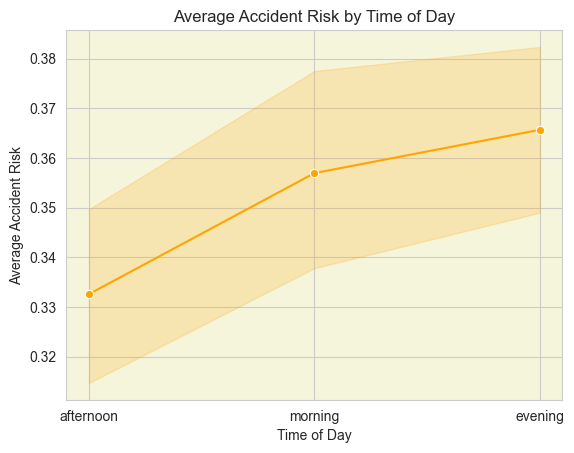

In [101]:
sns.lineplot(x="time_of_day", y="accident_risk", data=df, estimator="mean",
             sort=False, marker="o", color="orange")
plt.title("Average Accident Risk by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Accident Risk")
plt.show()


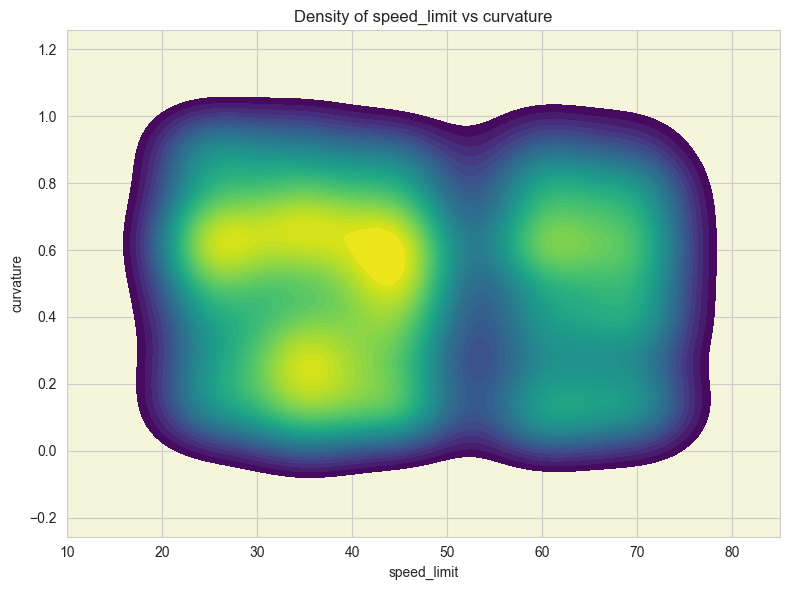

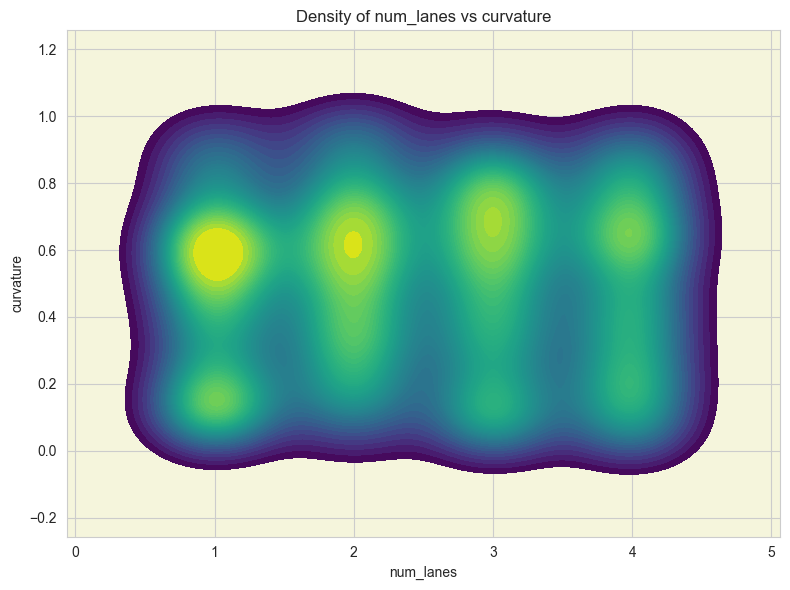

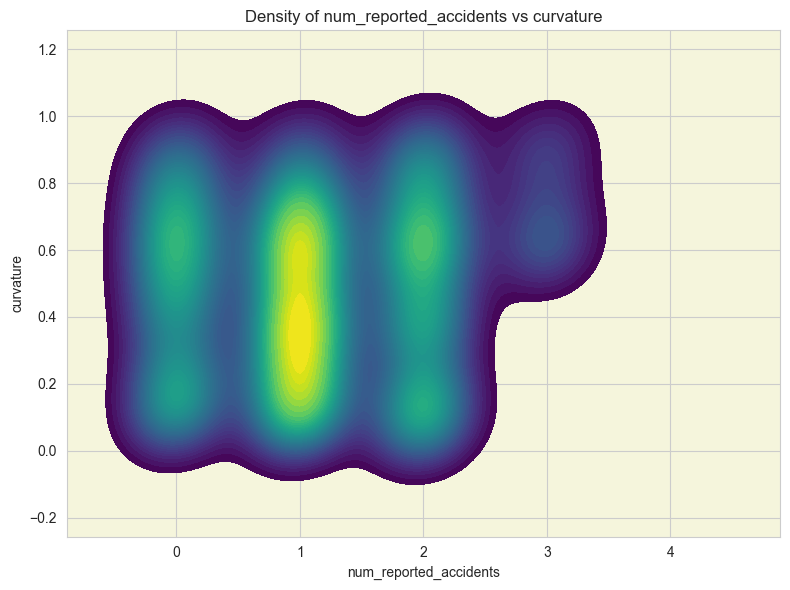

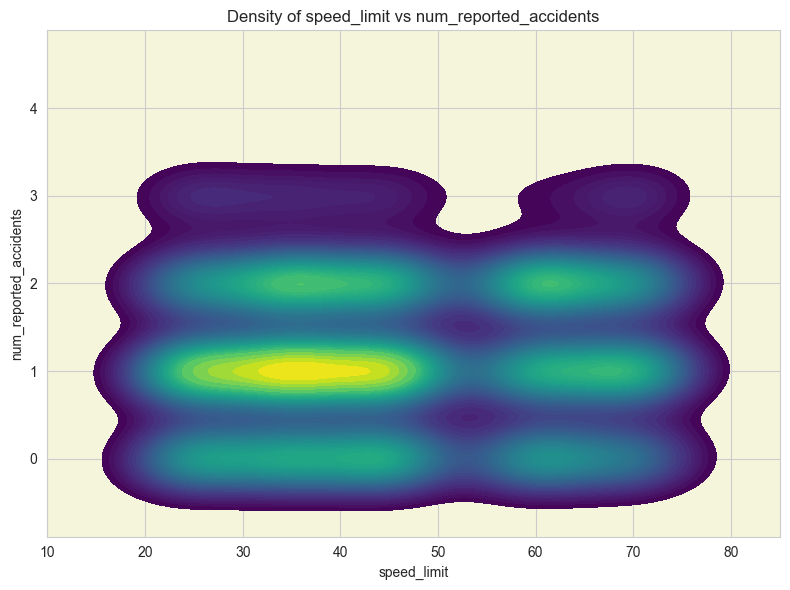

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define pairs of numeric features to visualize
feature_pairs = [
    ("speed_limit", "curvature"),
    ("num_lanes", "curvature"),
    ("num_reported_accidents", "curvature"),
    ("speed_limit", "num_reported_accidents")
]

for x_feat, y_feat in feature_pairs:
    plt.figure(figsize=(8,6))
    sns.kdeplot(
        data=df, x=x_feat, y=y_feat,
        fill=True, cmap="viridis", thresh=0.05, levels=50
    )
    plt.title(f"Density of {x_feat} vs {y_feat}")
    plt.xlabel(x_feat)
    plt.ylabel(y_feat)
    plt.tight_layout()
    plt.show()


C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\3616338772.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_risk = df.groupby('curvature_bin')['accident_risk'].mean().reset_index()
C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\3616338772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='curvature_bin', y='accident_risk', data=mean_risk, palette='viridis')


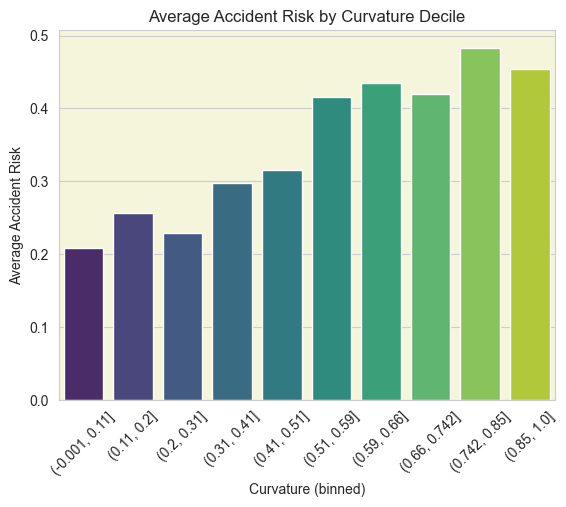

In [105]:
df['curvature_bin'] = pd.qcut(df['curvature'], q=10, duplicates='drop')
mean_risk = df.groupby('curvature_bin')['accident_risk'].mean().reset_index()

sns.barplot(x='curvature_bin', y='accident_risk', data=mean_risk, palette='viridis')
plt.xticks(rotation=45)
plt.title("Average Accident Risk by Curvature Decile")
plt.xlabel("Curvature (binned)")
plt.ylabel("Average Accident Risk")
plt.show()


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 50309 to 64061
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   road_type               1000 non-null   object  
 1   num_lanes               1000 non-null   int64   
 2   curvature               1000 non-null   float64 
 3   speed_limit             1000 non-null   int64   
 4   lighting                1000 non-null   object  
 5   weather                 1000 non-null   object  
 6   road_signs_present      1000 non-null   int32   
 7   public_road             1000 non-null   int32   
 8   time_of_day             1000 non-null   object  
 9   holiday                 1000 non-null   int32   
 10  school_season           1000 non-null   int32   
 11  num_reported_accidents  1000 non-null   int64   
 12  accident_risk           1000 non-null   float64 
 13  curvature_bin           1000 non-null   category
 14  speed_bin               

In [109]:
df = dff.sample(n=1000, random_state=42)  # losowa próbka 1000 wierszy

C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2841346591.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2841346591.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2841346591.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\2841346591.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

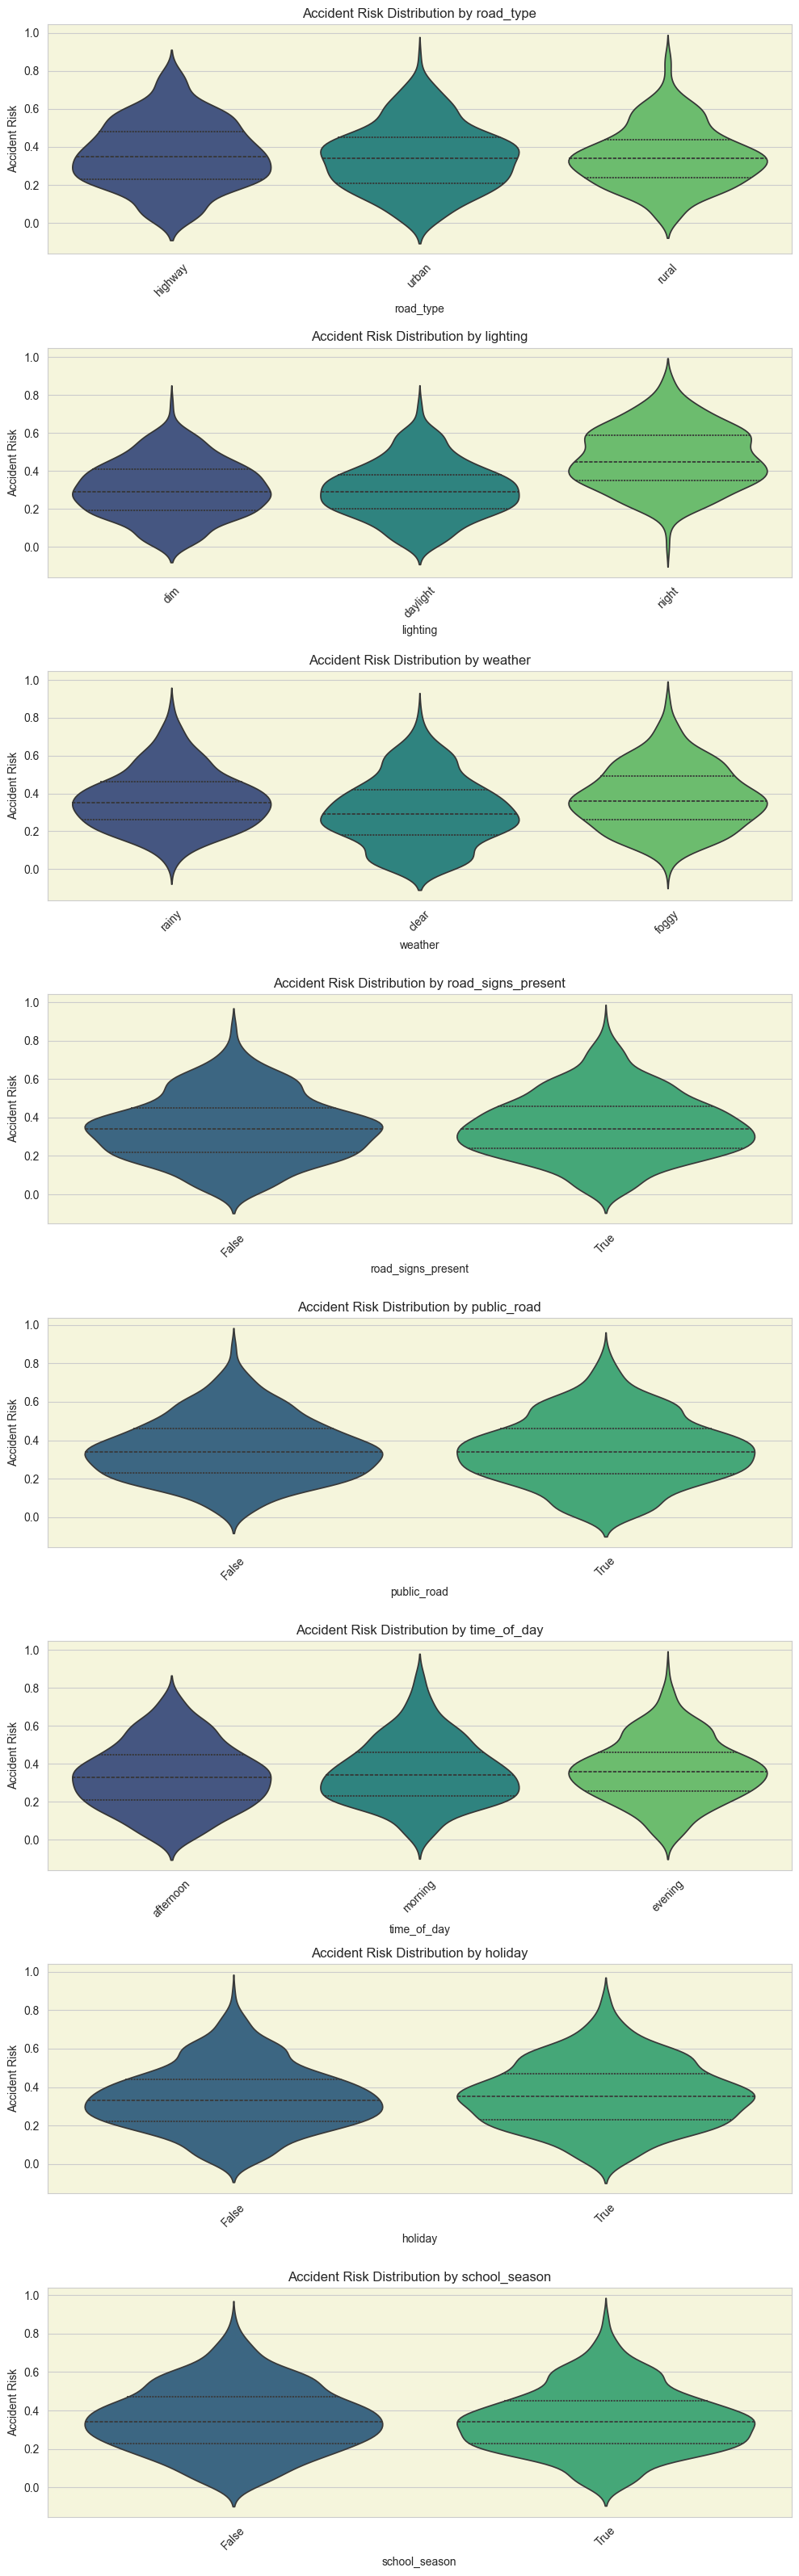

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Identify categorical and boolean features ---
categorical_features = df.select_dtypes(include=["object", "bool"]).columns.tolist()

# --- Create subplots ---
fig, axes = plt.subplots(len(categorical_features), 1, figsize=(10, 4 * len(categorical_features)))

if len(categorical_features) == 1:
    axes = [axes]

# --- Plot violin plots ---
for i, col in enumerate(categorical_features):
    sns.violinplot(
        x=col, 
        y="accident_risk", 
        data=df, 
        ax=axes[i], 
        palette="viridis", 
        inner="quartile"
    )
    axes[i].set_title(f"Accident Risk Distribution by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Accident Risk")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



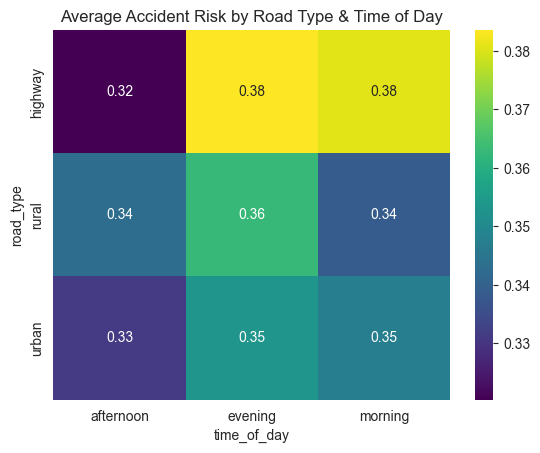

In [111]:
cross = df.pivot_table(index="road_type", columns="time_of_day", values="accident_risk", aggfunc="mean")
sns.heatmap(cross, annot=True, cmap="viridis")
plt.title("Average Accident Risk by Road Type & Time of Day")
plt.show()


C:\Users\szymo\AppData\Local\Temp\ipykernel_2796\4067729586.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="holiday", y="accident_risk", data=df, palette="viridis", size=3)


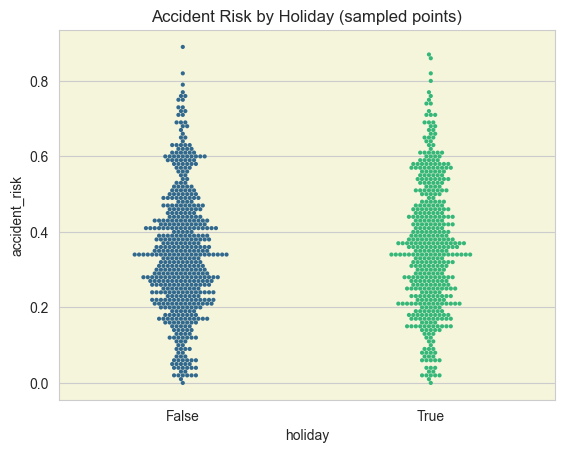

In [112]:
sns.swarmplot(x="holiday", y="accident_risk", data=df, palette="viridis", size=3)
plt.title("Accident Risk by Holiday (sampled points)")
plt.show()


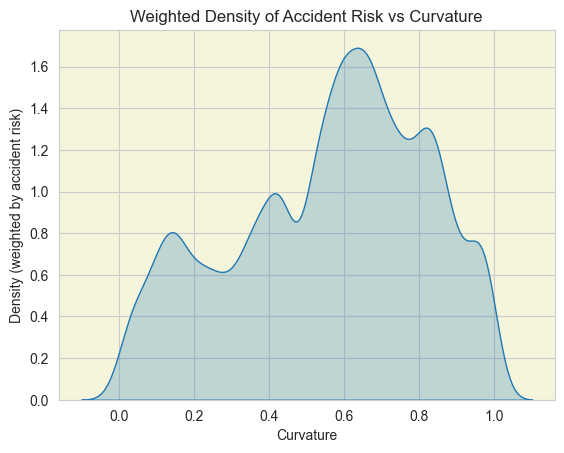

In [113]:
sns.kdeplot(data=df, x="curvature", weights=df["accident_risk"], fill=True, bw_adjust=0.5, cmap="viridis")
plt.title("Weighted Density of Accident Risk vs Curvature")
plt.xlabel("Curvature")
plt.ylabel("Density (weighted by accident risk)")
plt.show()


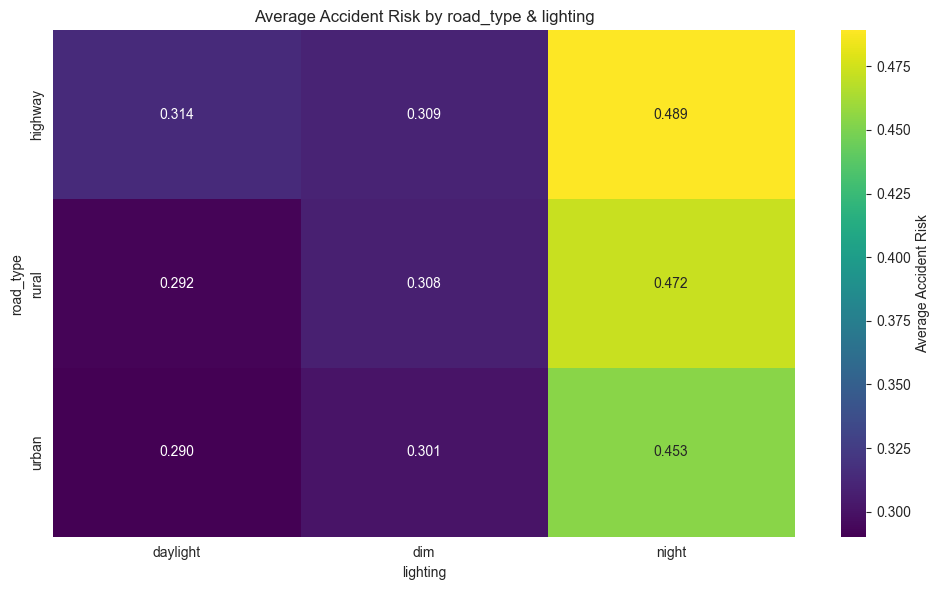

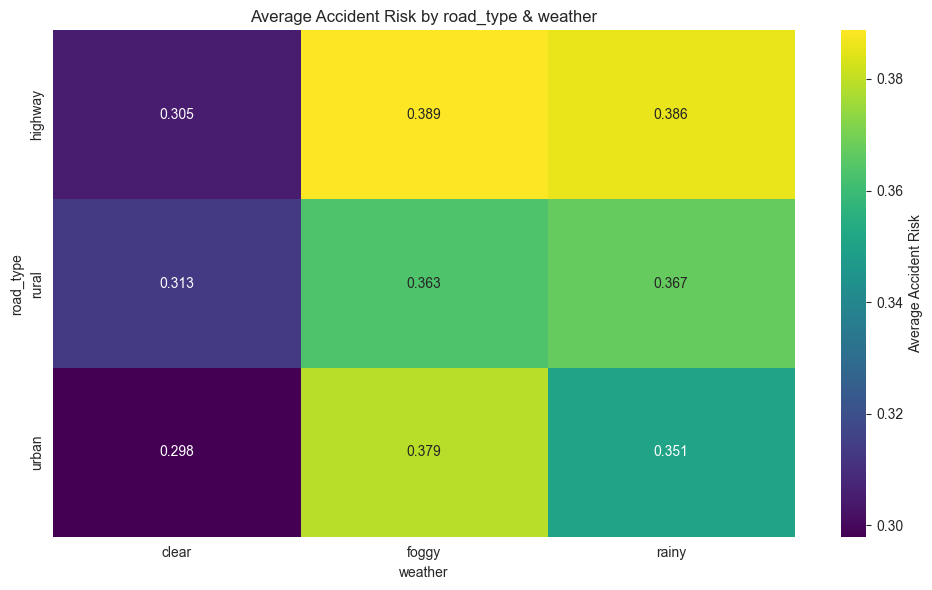

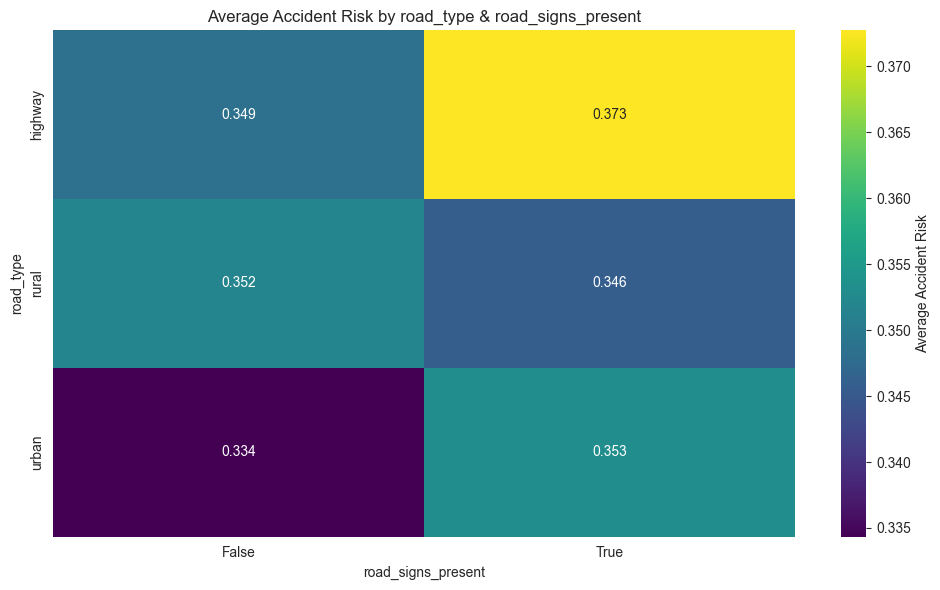

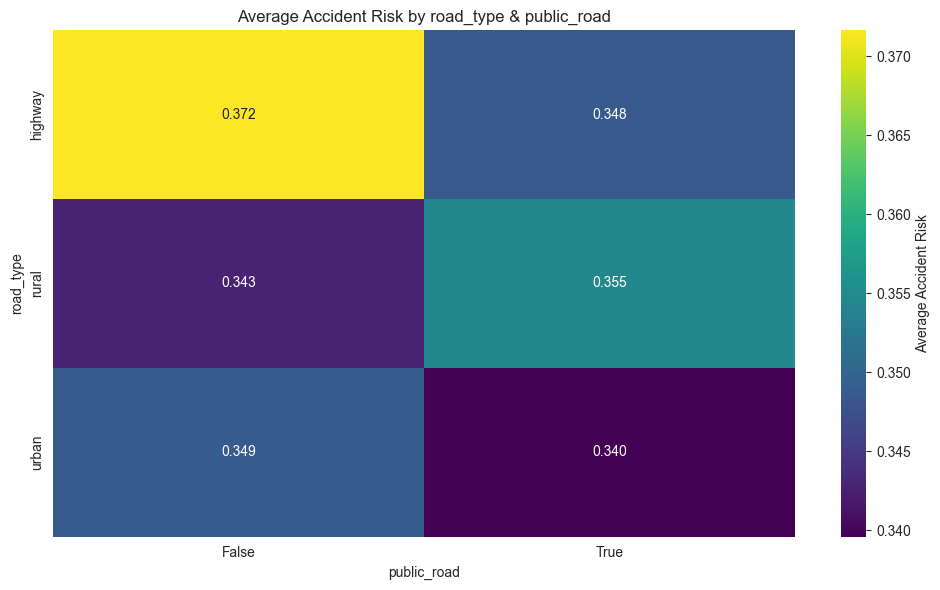

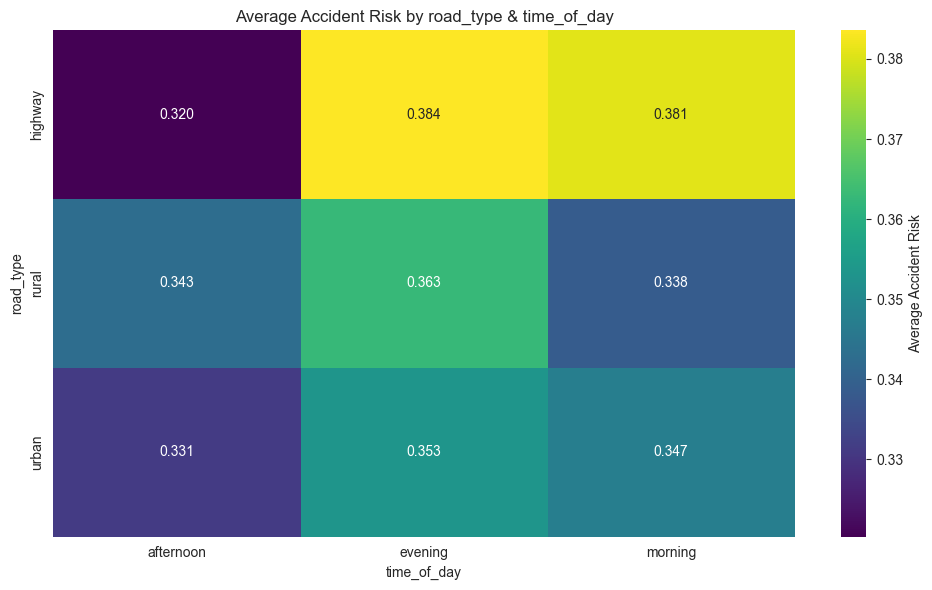

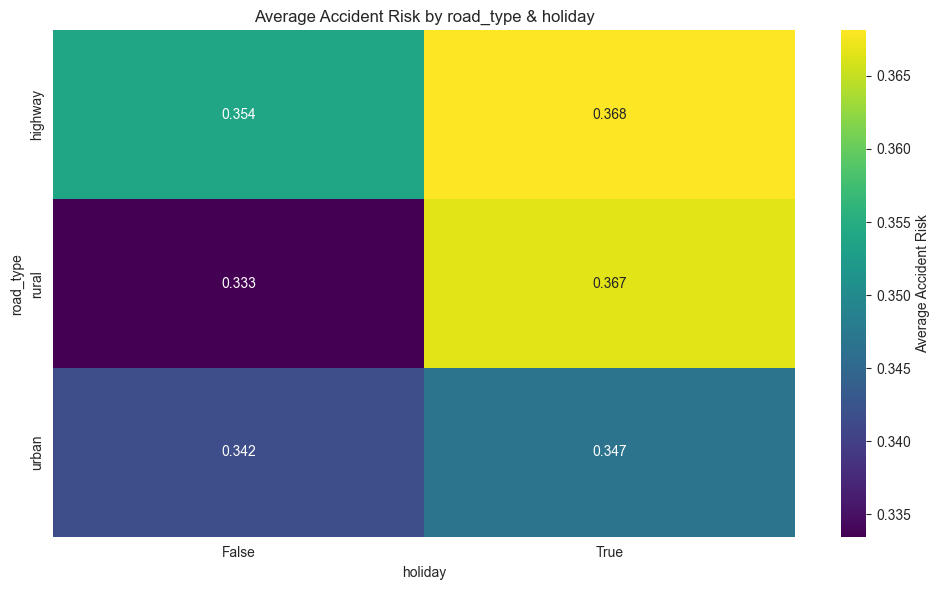

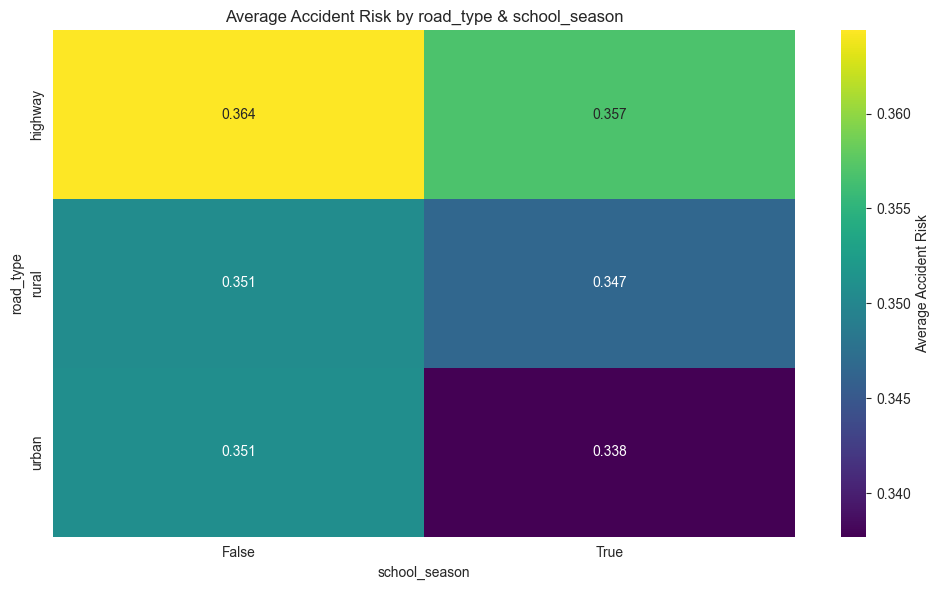

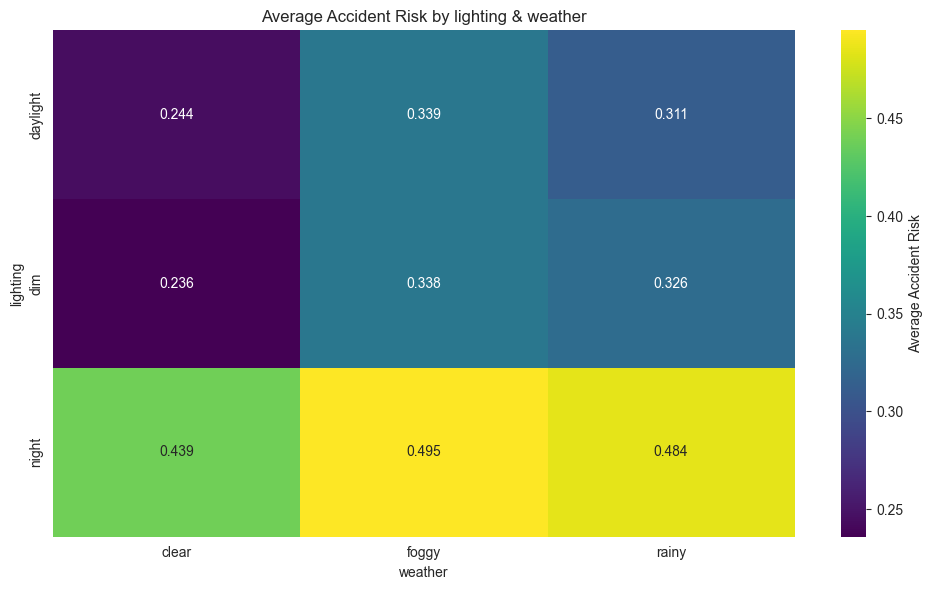

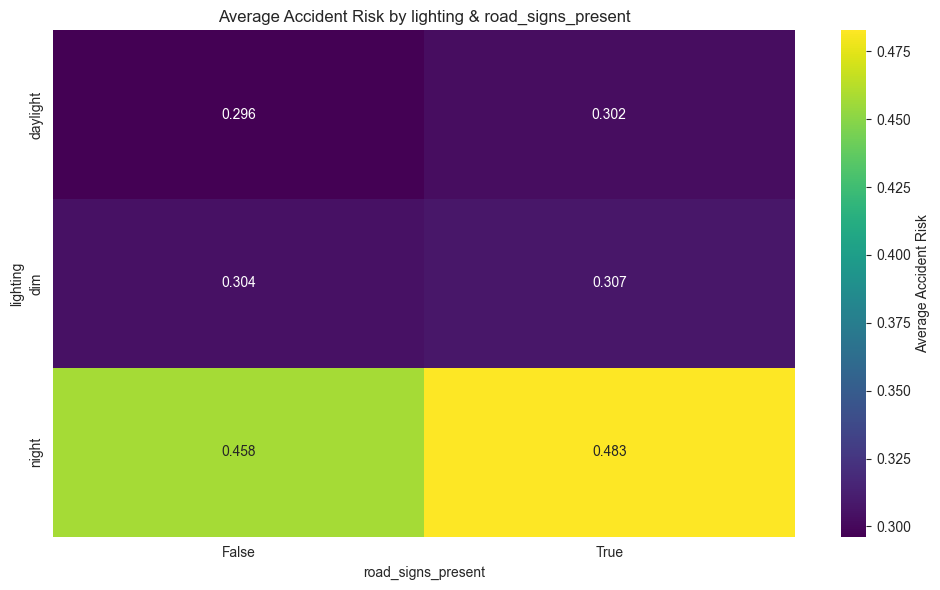

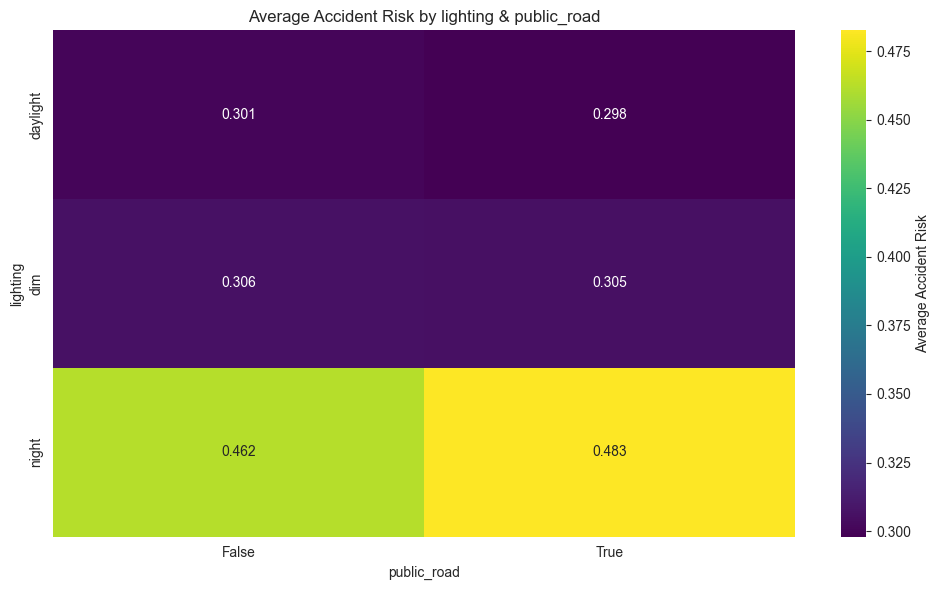

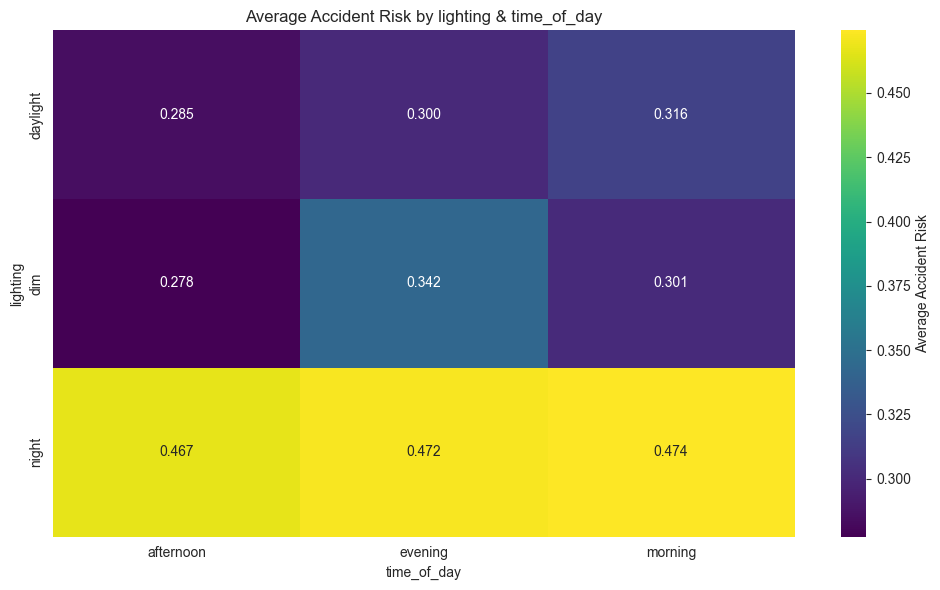

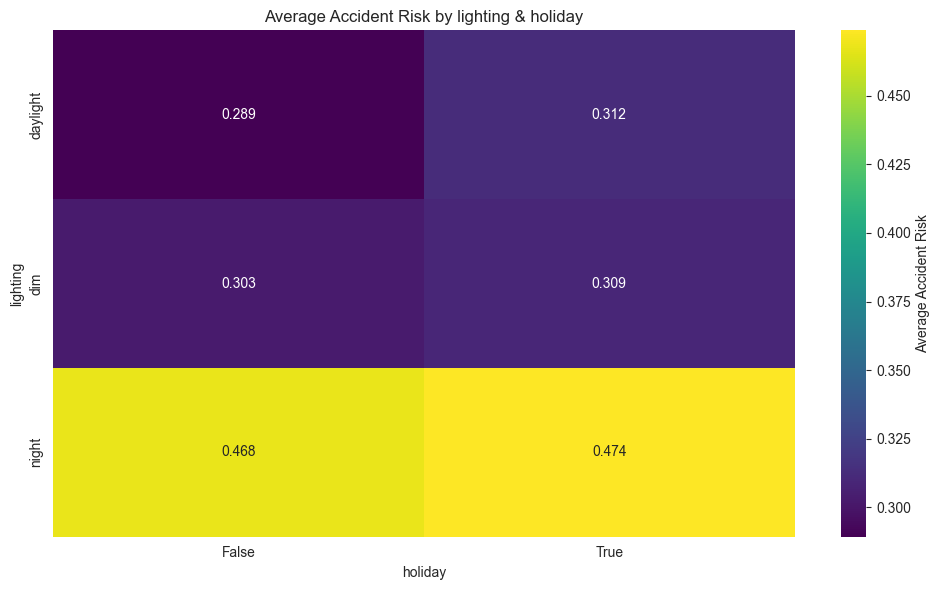

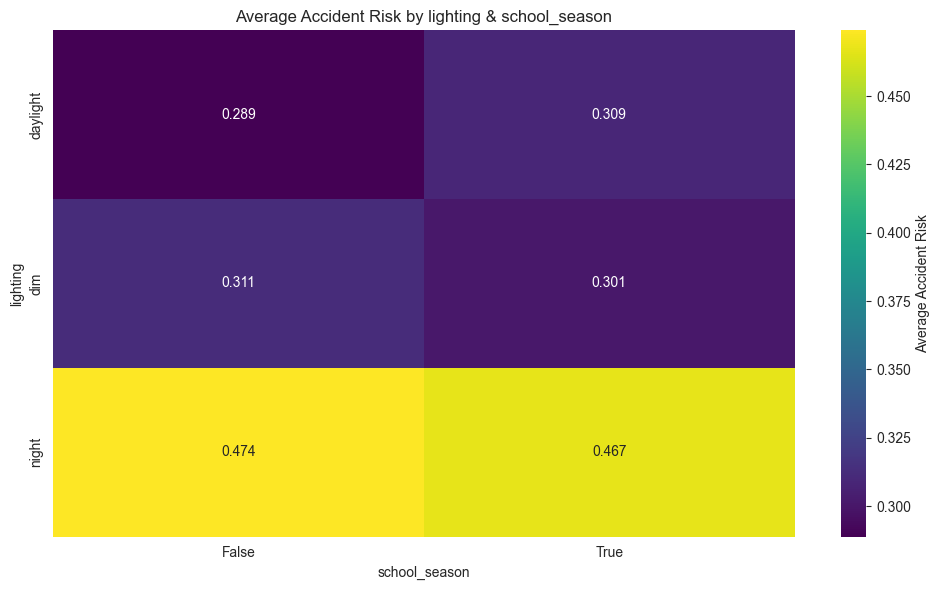

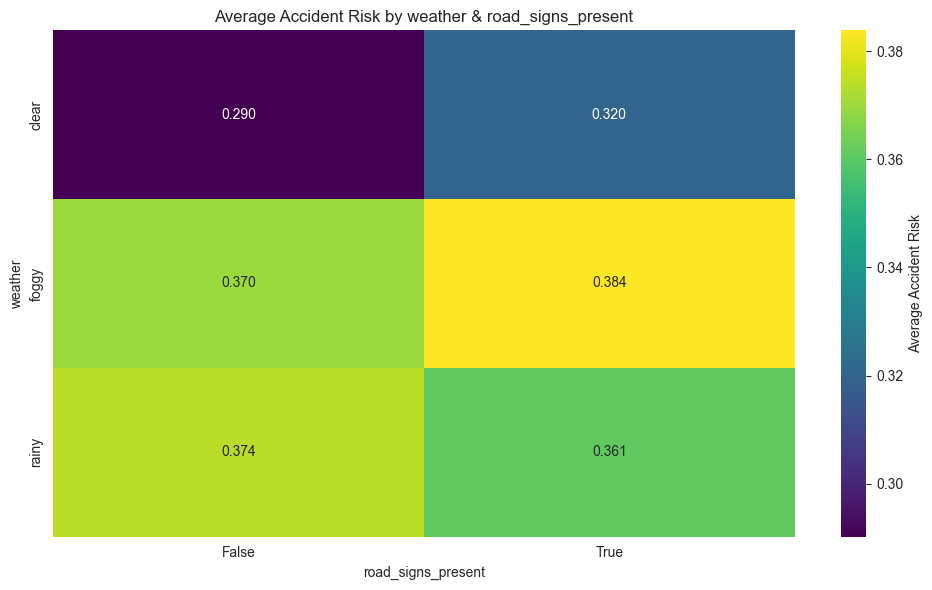

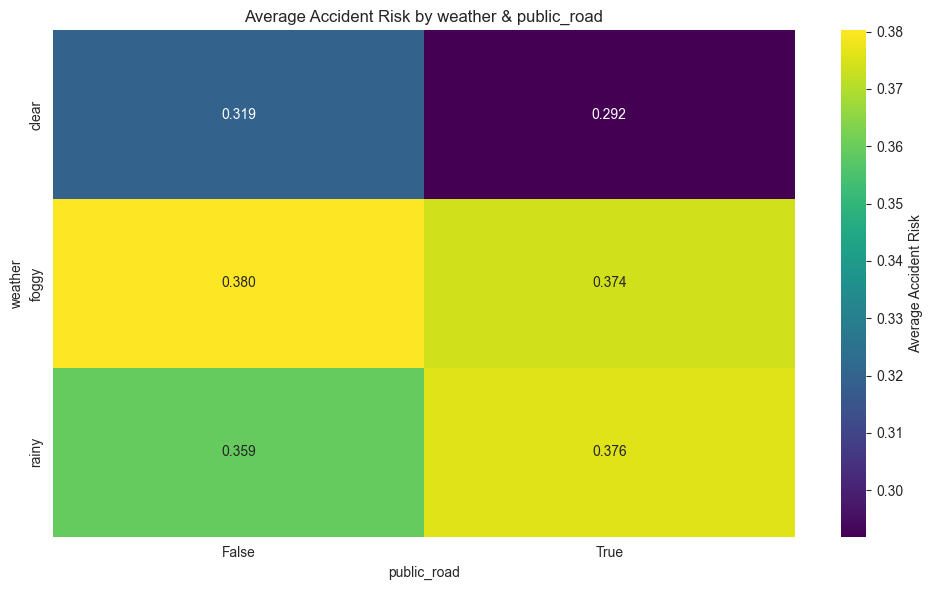

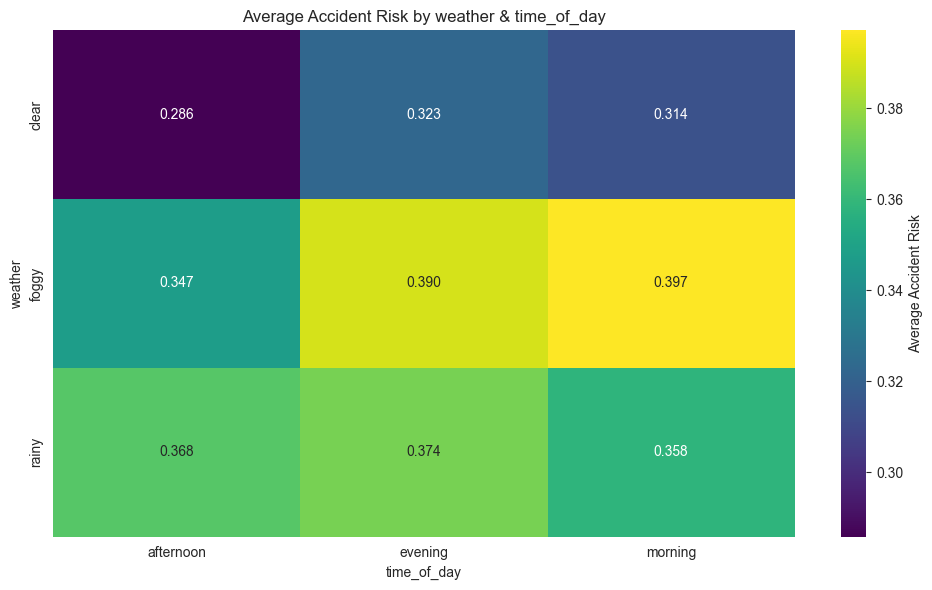

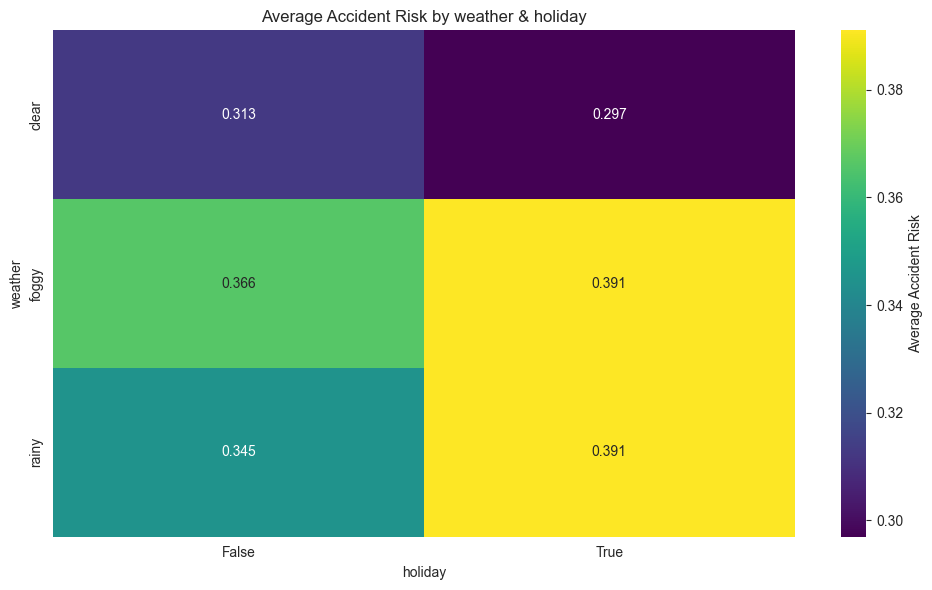

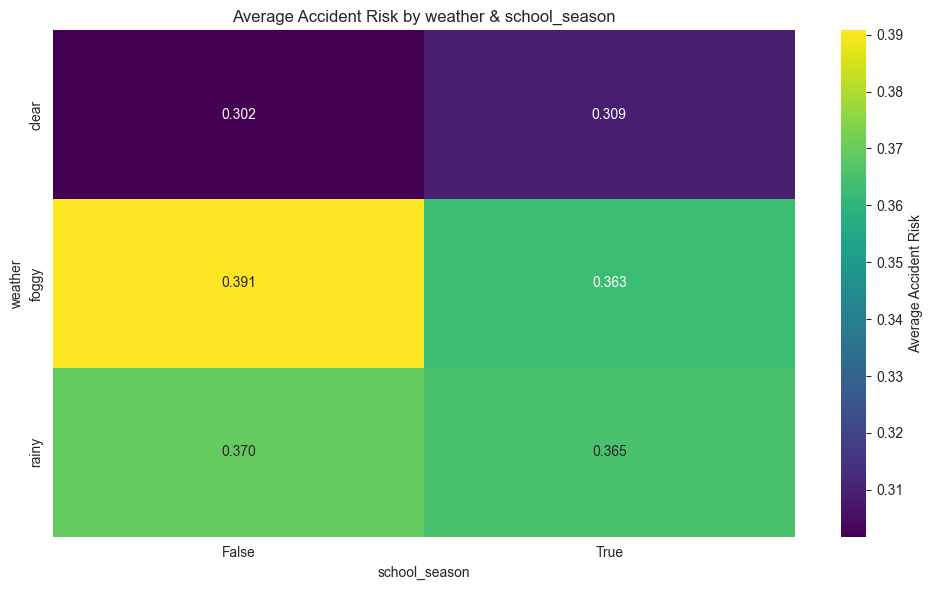

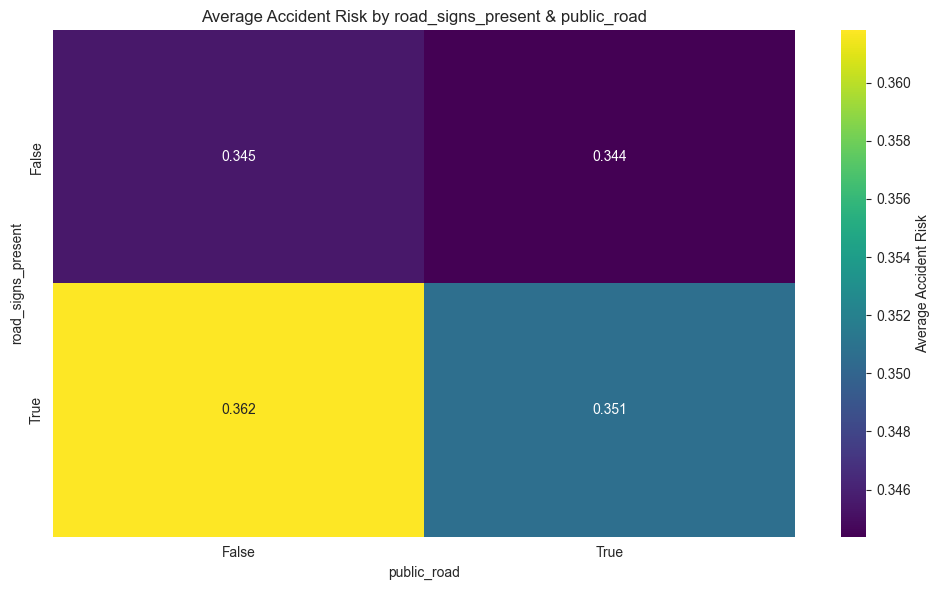

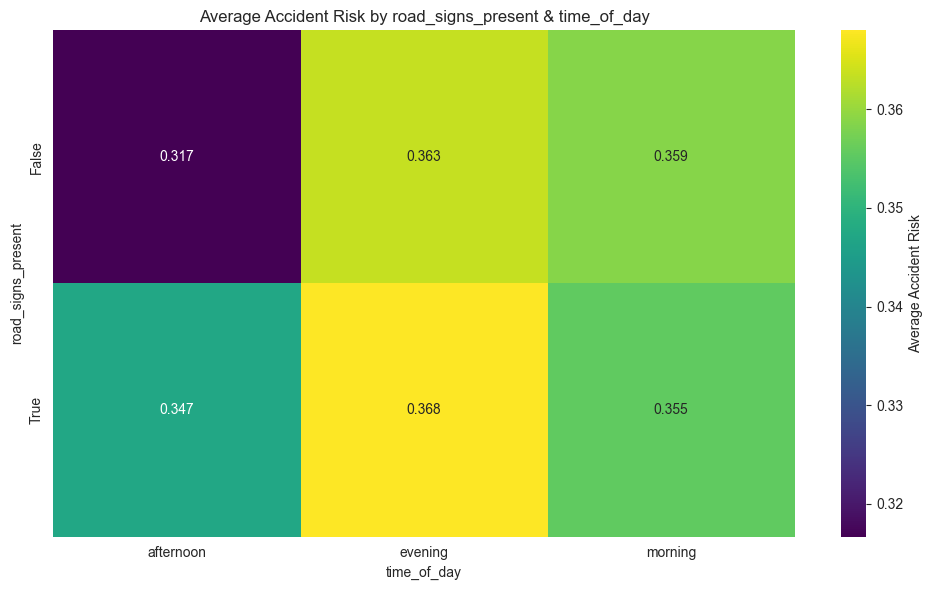

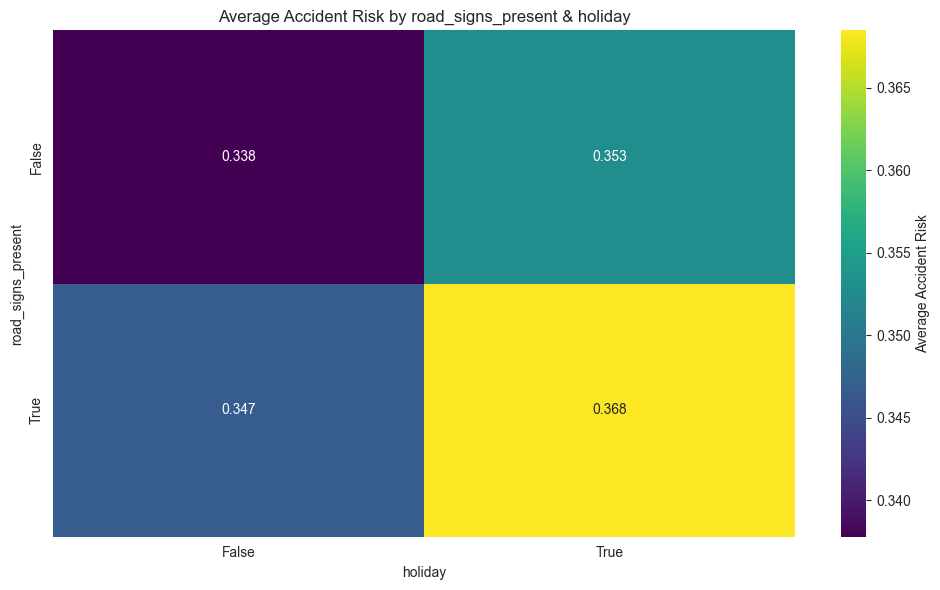

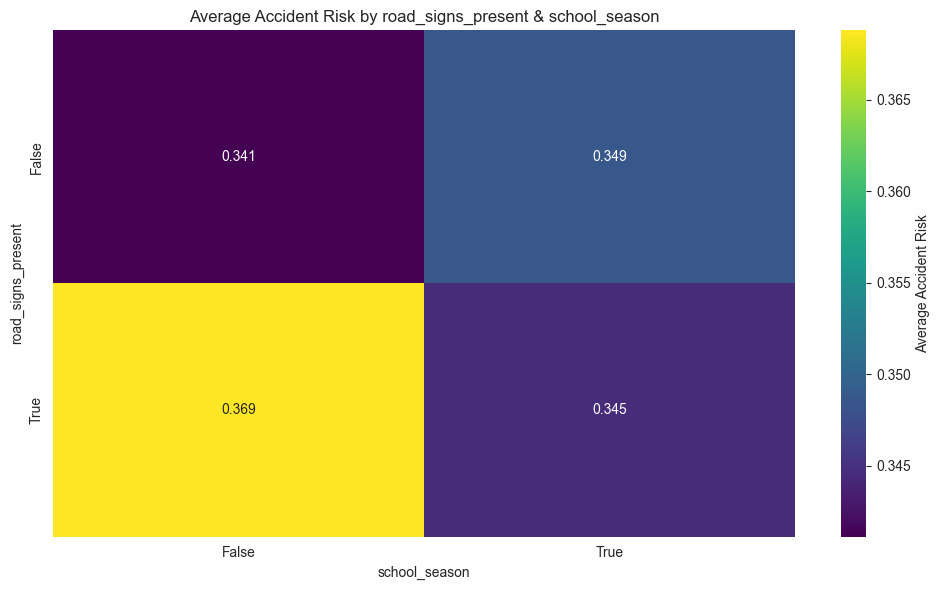

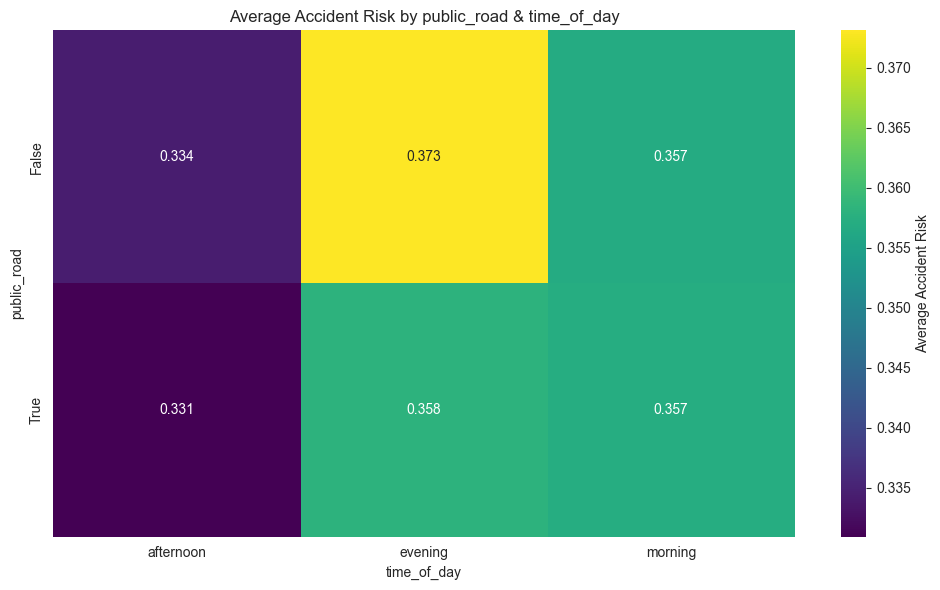

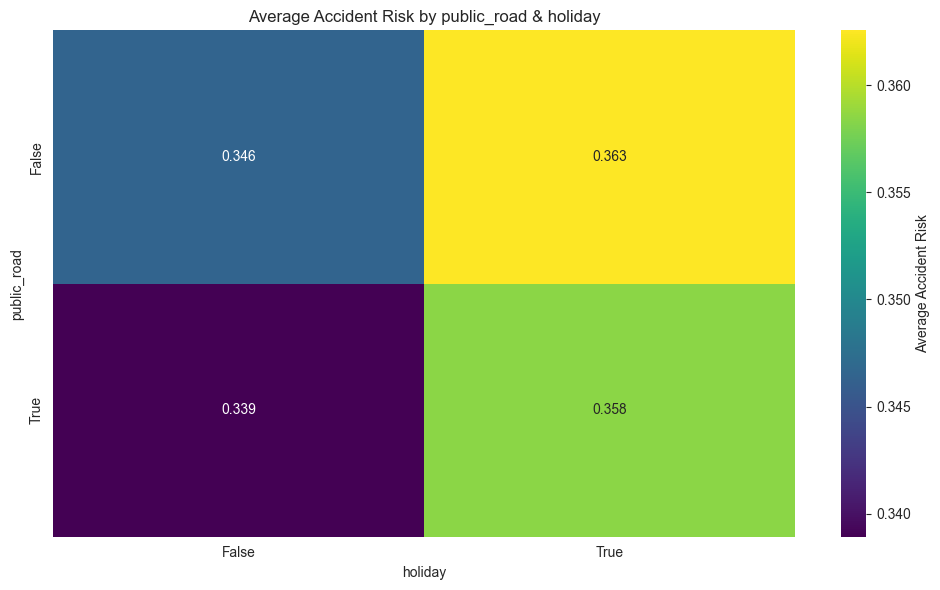

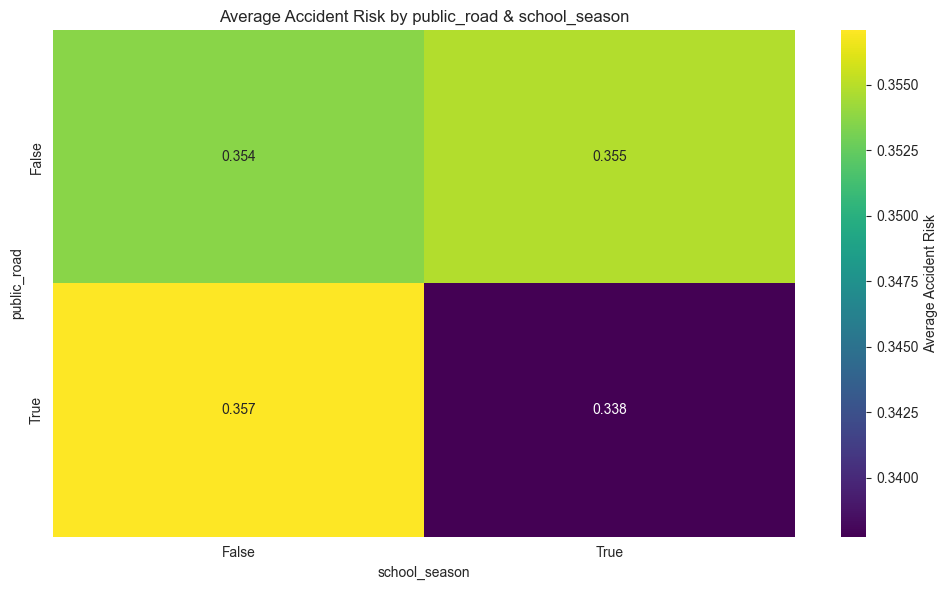

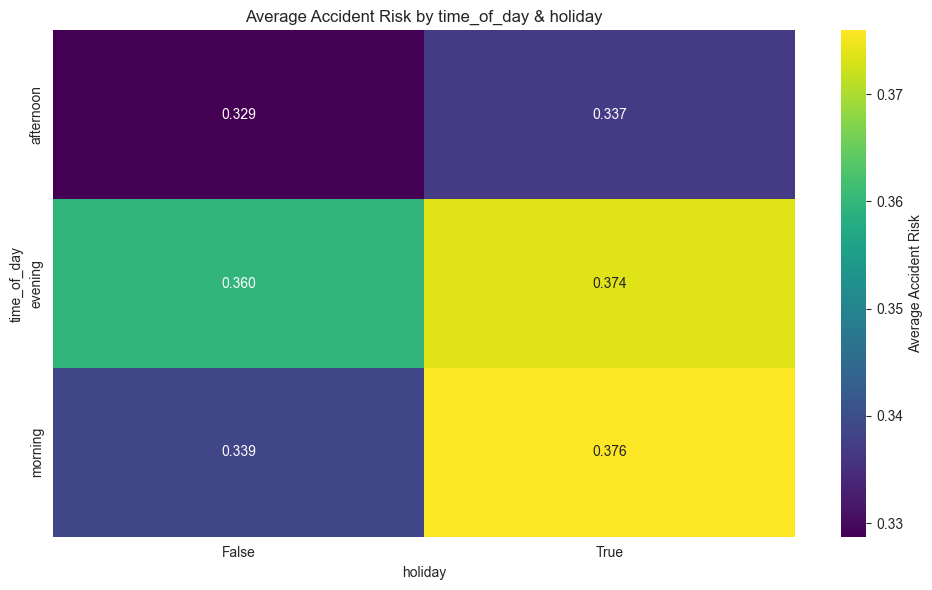

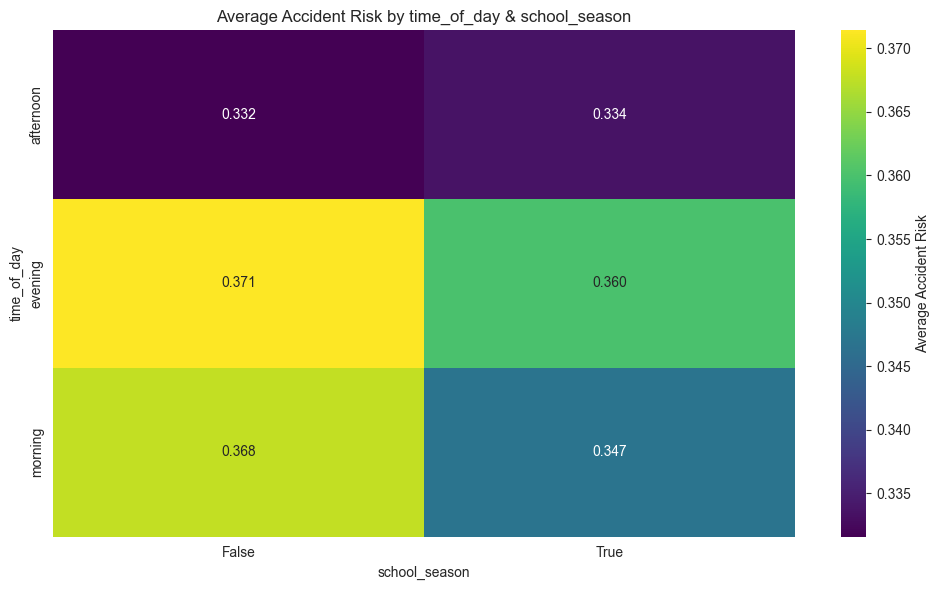

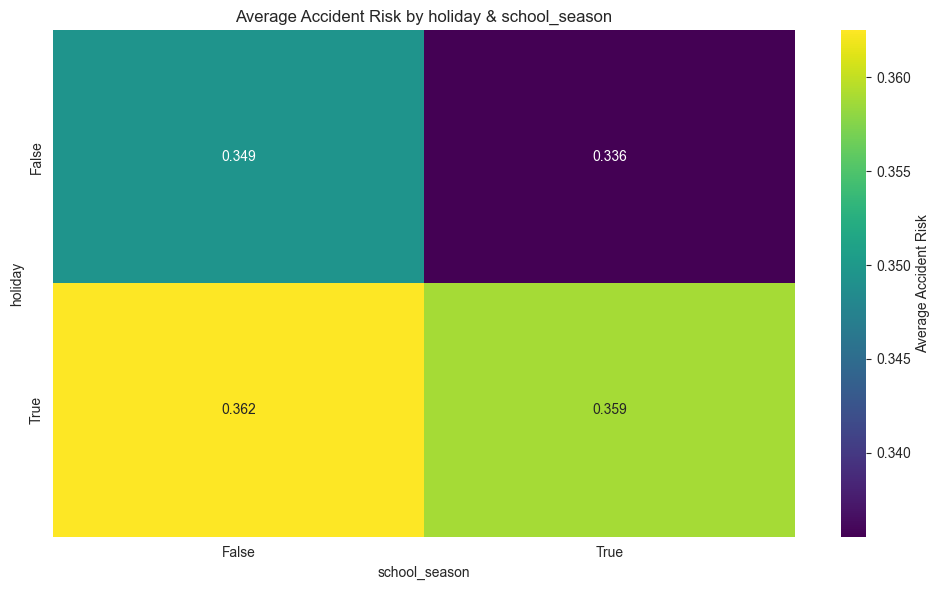

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# --- Identify categorical and boolean features ---
categorical_features = df.select_dtypes(include=["object", "bool"]).columns.tolist()

# --- Generate heatmaps for all pairs ---
for col1, col2 in combinations(categorical_features, 2):
    cross = df.pivot_table(
        index=col1,
        columns=col2,
        values="accident_risk",
        aggfunc="mean"
    )
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(cross, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Average Accident Risk'})
    plt.title(f"Average Accident Risk by {col1} & {col2}")
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()